/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device cpu
Loading weights from /Users/christiankwok/my wunderfund_challenge/wunderfund_challenge/competition_package/examples/delta+accel_scaled/lstm_weights.pt
Loading bias from /Users/christiankwok/my wunderfund_challenge/wunderfund_challenge/competition_package/examples/delta+accel_scaled/delta_bias.npy
Loading scale_delta from /Users/christiankwok/my wunderfund_challenge/wunderfund_challenge/competition_package/examples/delta+accel_scaled/scale_delta.npy
Loading scale_accel from /Users/christiankwok/my wunderfund_challenge/wunderfund_challenge/competition_package/examples/delta+accel_scaled/scale_accel.npy


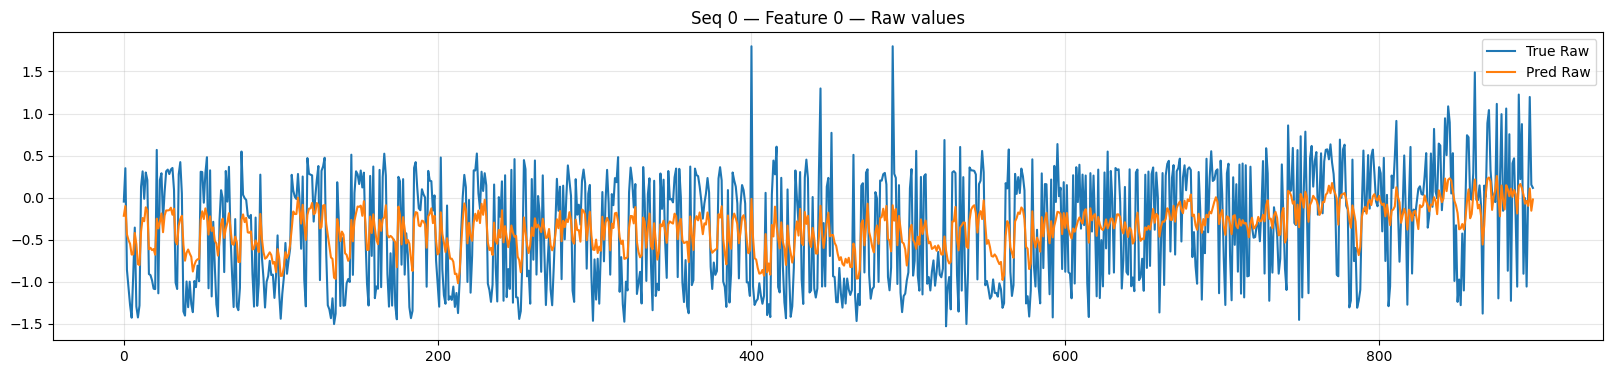

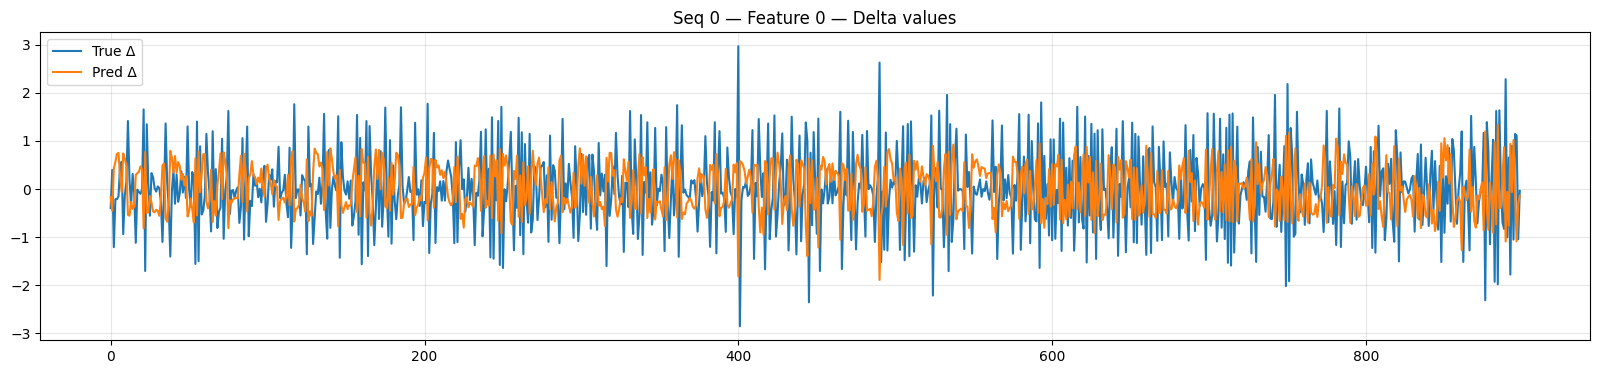

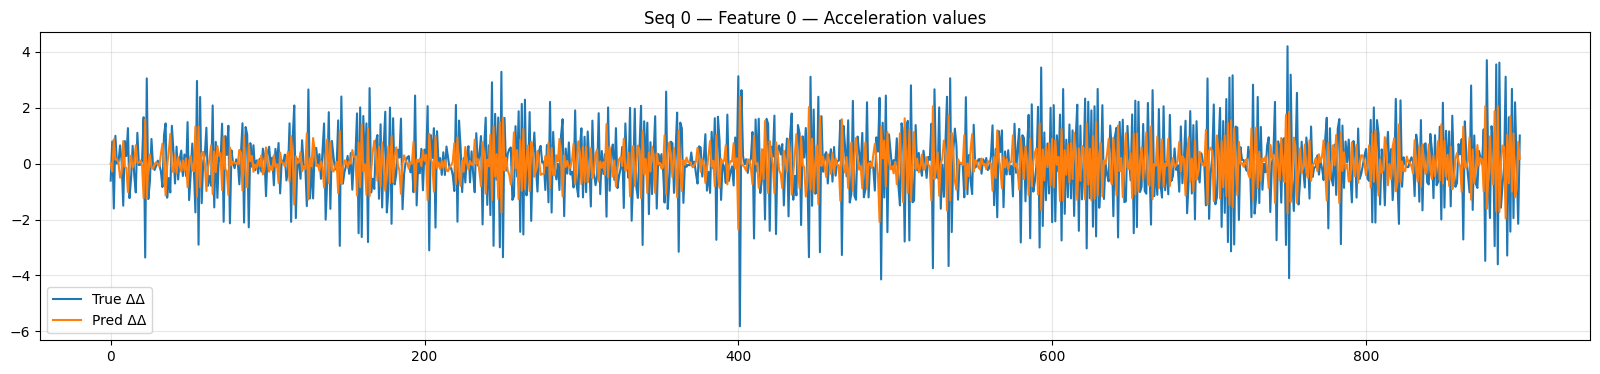

Done ✓


In [1]:
import os
import sys
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CURRENT_DIR = os.getcwd()

# make utils + solution visible
sys.path.append(f"{CURRENT_DIR}/../..")

from utils import ScorerStepByStep, DataPoint
from solution import PredictionModel   # <-- REQUIRED


# -------- choose sequence & feature to visualize --------
seq_ix = 0      # <---- change this
feat_ix = 0     # <---- change this  (0–31)
# --------------------------------------------------------


# Load dataset using same API as scorer
train_file = f"{CURRENT_DIR}/../../datasets/train.parquet"
scorer = ScorerStepByStep(train_file)
df = scorer.dataset

# Extract single sequence for visualization
df_seq = df[df["seq_ix"] == seq_ix].sort_values("step_in_seq").reset_index(drop=True)

# Load trained model (automatically loads weights/bias/gain if they exist)
model = PredictionModel()
model.eval()


true_raw, pred_raw = [], []
true_delta, pred_delta = [], []
true_accel, pred_accel = [], []

last_raw = None
last_delta = None

for _, row in df_seq.iterrows():
    dp = DataPoint(
        int(row["seq_ix"]),
        int(row["step_in_seq"]),
        bool(row["need_prediction"]),
        row[scorer.features].to_numpy(dtype=np.float32)
    )

    raw = dp.state.astype(np.float32)

    # true Δ (delta)
    if last_raw is None:
        delta_true = np.zeros_like(raw)
    else:
        delta_true = raw - last_raw

    # true ΔΔ (acceleration)
    if last_delta is None:
        accel_true = np.zeros_like(raw)
    else:
        accel_true = delta_true - last_delta

    last_raw = raw
    last_delta = delta_true

    pred = model.predict(dp)

    if pred is not None:   # only evaluate at scoring positions
        true_raw.append(raw[feat_ix])
        pred_raw.append(pred[feat_ix])

        true_delta.append(delta_true[feat_ix])
        pred_delta.append(pred[feat_ix] - raw[feat_ix])

        true_accel.append(accel_true[feat_ix])
        if len(pred_delta) < 2:
            pred_accel.append(0)
        else:
            pred_accel.append(pred_delta[-1] - pred_delta[-2])


# convert to arrays
true_raw = np.array(true_raw)
pred_raw = np.array(pred_raw)
true_delta = np.array(true_delta)
pred_delta = np.array(pred_delta)
true_accel = np.array(true_accel)
pred_accel = np.array(pred_accel)

# ---------- PLOTS ----------
x = np.arange(len(true_raw))

plt.figure(figsize=(20,4))
plt.plot(x, true_raw, label="True Raw")
plt.plot(x, pred_raw, label="Pred Raw")
plt.title(f"Seq {seq_ix} — Feature {feat_ix} — Raw values")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(20,4))
plt.plot(x, true_delta, label="True Δ")
plt.plot(x, pred_delta, label="Pred Δ")
plt.title(f"Seq {seq_ix} — Feature {feat_ix} — Delta values")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(20,4))
plt.plot(x, true_accel, label="True ΔΔ")
plt.plot(x, pred_accel, label="Pred ΔΔ")
plt.title(f"Seq {seq_ix} — Feature {feat_ix} — Acceleration values")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("Done ✓")
